In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install --ignore-installed blinker
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 160.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ============================================================
# TELECOM CUSTOMER CHURN PREDICTION - ML PIPELINE
# Baseline Models + Hyperparameter Tuning + MLflow
# ============================================================

# ============================================================
# INSTALL / IMPORT LIBRARIES
# ============================================================

!pip install -q mlflow xgboost

import pandas as pd
import numpy as np
import os
import joblib
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 1.3 MB/s eta 0:00:00
Libraries imported successfully


In [5]:
import pandas as pd
import numpy as np

# Load cleaned dataset
master_df = pd.read_csv(
    "/content/drive/MyDrive/ADSProject/Project_Root/Final_Cleaned_Dataset/master_df.csv"
)



print("Shape:", master_df.shape)
master_df.head()

Shape: (7043, 47)


,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Referred a Friend,Number of Referrals,Tenure in Months,...,Churn Value,Churn Score,CLTV,Churn Reason,City,Zip Code,Lat Long,Latitude,Longitude,Population
0,Male,78,No,Yes,No,No,0,No,0,1,...,1,91,5433,Competitor offered more data,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,68701
1,Female,74,No,Yes,Yes,Yes,1,Yes,1,8,...,1,69,5302,Competitor made better offer,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237,55668
2,Male,71,No,Yes,No,Yes,3,No,0,18,...,1,81,3179,Competitor made better offer,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715,47534
3,Female,78,No,Yes,Yes,Yes,1,Yes,1,25,...,1,88,5337,Limited range of services,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639,27778
4,Female,80,No,Yes,Yes,Yes,1,Yes,1,37,...,1,67,2793,Extra data charges,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188,26265


In [6]:
# Target Variable



print("Churn Label distribution:")
print(master_df["Churn Label"].value_counts())

print("\nPercentage:")
print(
    master_df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn Label distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [7]:
# Remove Target Leakage

target = "Churn Label"

# Columns that directly reveal churn outcome
leakage_columns = [
    "Churn Value",
    "Churn Reason",
    "Customer Status",
    "Churn Score"
]

# Remove only columns that exist
leakage_columns = [
    col for col in leakage_columns
    if col in master_df.columns
]

print("Removing leakage columns:")
print(leakage_columns)

X = master_df.drop(columns=[target] + leakage_columns)
y = master_df[target]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Removing leakage columns:
['Churn Value', 'Churn Reason', 'Customer Status', 'Churn Score']

X shape: (7043, 42)
y shape: (7043,)


In [8]:
# Encode Target

print("Original target values:")
print(y.unique())

# Yes = 1, No = 0
y = y.map({
    "Yes": 1,
    "No": 0
})

print("\nEncoded target:")
print(y.value_counts())

Original target values:
['Yes' 'No']

Encoded target:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [9]:

#  TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data: (5634, 42)
Testing data : (1409, 42)

Training target distribution:
Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target distribution:
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [10]:
# Identifying Categorical and Numerical Fetaures

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numerical features: 18
Categorical features: 24

Numerical:
['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLTV', 'Zip Code', 'Latitude', 'Longitude', 'Population']

Categorical:
['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'City', 'Lat Long']


In [11]:
# Preprocessing

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [12]:
# Baseline Models

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- XGBoost


In [13]:
# Train Baseline Models

baseline_results = []
baseline_pipelines = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    baseline_pipelines[name] = pipeline

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))


Training: Logistic Regression
Accuracy : 0.9595
Precision: 0.9542
Recall   : 0.8904
F1 Score : 0.9212
ROC-AUC  : 0.9913

Training: Decision Tree
Accuracy : 0.9489
Precision: 0.9194
Recall   : 0.885
F1 Score : 0.9019
ROC-AUC  : 0.9285

Training: Random Forest
Accuracy : 0.9297
Precision: 0.9508
Recall   : 0.7754
F1 Score : 0.8542
ROC-AUC  : 0.9649

Training: SVM
Accuracy : 0.9595
Precision: 0.9731
Recall   : 0.8717
F1 Score : 0.9196
ROC-AUC  : 0.9885

Training: XGBoost
Accuracy : 0.9674
Precision: 0.974
Recall   : 0.9011
F1 Score : 0.9361
ROC-AUC  : 0.9921


In [14]:
# Compare

baseline_df = pd.DataFrame(baseline_results)

baseline_df = baseline_df.sort_values(
    "F1 Score",
    ascending=False
)

baseline_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.9674,0.9740,0.9011,0.9361,0.9921
0,Logistic Regression,0.9595,0.9542,0.8904,0.9212,0.9913
3,SVM,0.9595,0.9731,0.8717,0.9196,0.9885
1,Decision Tree,0.9489,0.9194,0.8850,0.9019,0.9285
2,Random Forest,0.9297,0.9508,0.7754,0.8542,0.9649


<Figure size 1000x500 with 0 Axes>

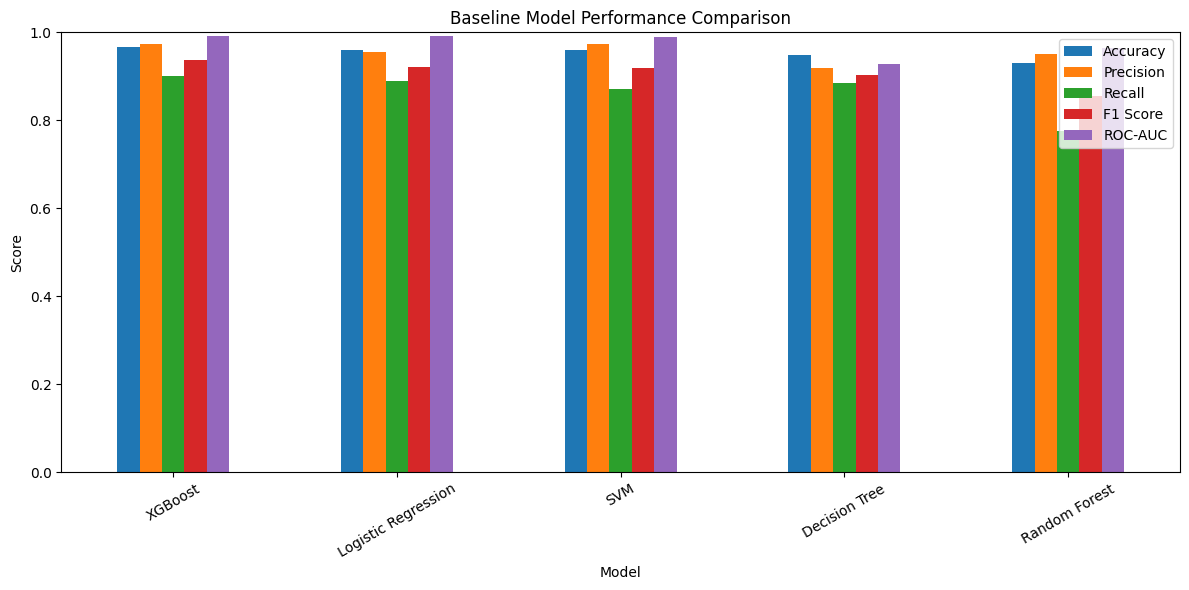

In [15]:
# Visualize Model Comparison

plt.figure(figsize=(10, 5))

baseline_plot = baseline_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

baseline_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

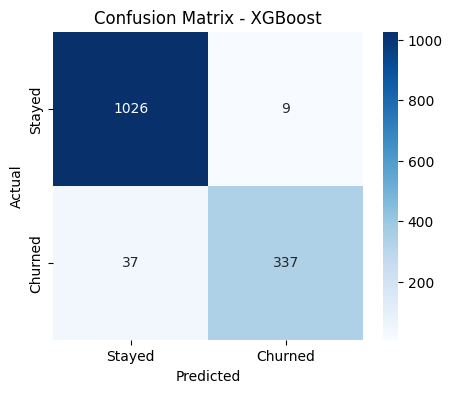

Best baseline: XGBoost
              precision    recall  f1-score   support

      Stayed       0.97      0.99      0.98      1035
     Churned       0.97      0.90      0.94       374

    accuracy                           0.97      1409
   macro avg       0.97      0.95      0.96      1409
weighted avg       0.97      0.97      0.97      1409



In [16]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

best_baseline_name = baseline_df.iloc[0]["Model"]

best_baseline_model = baseline_pipelines[
    best_baseline_name
]

y_pred_best = best_baseline_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_baseline_name}")
plt.show()

print("Best baseline:", best_baseline_name)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["Stayed", "Churned"]
    )
)

In [17]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV F1 Score:")
print(round(rf_grid.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Random Forest Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV F1 Score:
0.8503


In [18]:
# ============================================================
# EVALUATE TUNED RANDOM FOREST
# ============================================================

rf_best = rf_grid.best_estimator_

rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_prob)

tuned_rf_result = {
    "Model": "Random Forest Tuned",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_auc
}

print("Random Forest - Tuned")

for key, value in tuned_rf_result.items():
    if key != "Model":
        print(f"{key}: {value:.4f}")

Random Forest - Tuned
Accuracy: 0.9297
Precision: 0.9508
Recall: 0.7754
F1 Score: 0.8542
ROC-AUC: 0.9649


In [19]:
# ============================================================
# SVM HYPERPARAMETER TUNING
# ============================================================

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_params = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest CV F1 Score:")
print(round(svm_grid.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best SVM Parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best CV F1 Score:
0.9239


In [20]:
# ============================================================
# EVALUATE TUNED SVM
# ============================================================

svm_best = svm_grid.best_estimator_

svm_pred = svm_best.predict(X_test)
svm_prob = svm_best.predict_proba(X_test)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, zero_division=0)
svm_auc = roc_auc_score(y_test, svm_prob)

tuned_svm_result = {
    "Model": "SVM Tuned",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "ROC-AUC": svm_auc
}

print("SVM - Tuned")

for key, value in tuned_svm_result.items():
    if key != "Model":
        print(f"{key}: {value:.4f}")

SVM - Tuned
Accuracy: 0.9631
Precision: 0.9735
Recall: 0.8850
F1 Score: 0.9272
ROC-AUC: 0.9904


In [21]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

tuned_results = pd.DataFrame([
    tuned_rf_result,
    tuned_svm_result
])

all_results = pd.concat(
    [
        baseline_df,
        tuned_results
    ],
    ignore_index=True
)

all_results = all_results.sort_values(
    "F1 Score",
    ascending=False
)

print("\nFINAL MODEL COMPARISON")
print("=" * 70)

display(all_results.round(4))


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9674,0.9740,0.9011,0.9361,0.9921
6,SVM Tuned,0.9631,0.9735,0.8850,0.9272,0.9904
1,Logistic Regression,0.9595,0.9542,0.8904,0.9212,0.9913
2,SVM,0.9595,0.9731,0.8717,0.9196,0.9885
3,Decision Tree,0.9489,0.9194,0.8850,0.9019,0.9285
4,Random Forest,0.9297,0.9508,0.7754,0.8542,0.9649
5,Random Forest Tuned,0.9297,0.9508,0.7754,0.8542,0.9649


In [22]:
# ============================================================
# BASELINE VS TUNED
# ============================================================

rf_baseline = baseline_df[
    baseline_df["Model"] == "Random Forest"
].iloc[0]

svm_baseline = baseline_df[
    baseline_df["Model"] == "SVM"
].iloc[0]

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Random Forest Baseline": [
        rf_baseline["Accuracy"],
        rf_baseline["Precision"],
        rf_baseline["Recall"],
        rf_baseline["F1 Score"],
        rf_baseline["ROC-AUC"]
    ],

    "Random Forest Tuned": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ],

    "SVM Baseline": [
        svm_baseline["Accuracy"],
        svm_baseline["Precision"],
        svm_baseline["Recall"],
        svm_baseline["F1 Score"],
        svm_baseline["ROC-AUC"]
    ],

    "SVM Tuned": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ]
})

display(comparison.round(4))

,Metric,Random Forest Baseline,Random Forest Tuned,SVM Baseline,SVM Tuned
0,Accuracy,0.9297,0.9297,0.9595,0.9631
1,Precision,0.9508,0.9508,0.9731,0.9735
2,Recall,0.7754,0.7754,0.8717,0.8850
3,F1 Score,0.8542,0.8542,0.9196,0.9272
4,ROC-AUC,0.9649,0.9649,0.9885,0.9904


In [23]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_row = all_results.iloc[0]

best_model_name = best_model_row["Model"]

print("BEST MODEL")
print("=" * 40)
print("Model   :", best_model_name)
print("Accuracy:", round(best_model_row["Accuracy"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall  :", round(best_model_row["Recall"], 4))
print("F1      :", round(best_model_row["F1 Score"], 4))
print("ROC-AUC :", round(best_model_row["ROC-AUC"], 4))

BEST MODEL
Model   : XGBoost
Accuracy: 0.9674
Precision: 0.974
Recall  : 0.9011
F1      : 0.9361
ROC-AUC : 0.9921


In [24]:
# ============================================================
# BEST MODEL OBJECT
# ============================================================

if best_model_name == "Random Forest Tuned":
    final_model = rf_best

elif best_model_name == "SVM Tuned":
    final_model = svm_best

else:
    final_model = baseline_pipelines[best_model_name]

print("Final model selected:", best_model_name)

Final model selected: XGBoost


In [25]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

MODEL_DIR = "/content/Telecom-Customer-Churn-Prediction/models"

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "best_churn_model.pkl"
)

joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
/content/Telecom-Customer-Churn-Prediction/models/best_churn_model.pkl


In [26]:
import os
import joblib

# ============================================================
# SAVE BEST MODEL TO GOOGLE DRIVE
# ============================================================

# Specify your target Google Drive folder
MODEL_DIR = "/content/drive/MyDrive/ADSProject/Project_Root/Models"

# Create the folder in Drive if it doesn't already exist
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "best_churn_model.pkl"
)

# Save model
joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully to Google Drive:")
print(model_path)

Model saved successfully to Google Drive:
/content/drive/MyDrive/ADSProject/Project_Root/Models/best_churn_model.pkl


In [27]:
# ============================================================
# TEST SAVED MODEL
# ============================================================

loaded_model = joblib.load(model_path)

test_prediction = loaded_model.predict(X_test)

print(
    "Saved model accuracy:",
    round(
        accuracy_score(y_test, test_prediction),
        4
    )
)

Saved model accuracy: 0.9674


MLFlow EXperiment

In [28]:
# ============================================================
# MLFLOW SETUP
# ============================================================

mlflow.set_experiment("Telecom_Customer_Churn")

print("MLflow experiment configured")

2026/09/21 17:20:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/21 17:20:52 INFO mlflow.store.db.utils: Updating database tables
2026/09/21 17:20:54 INFO mlflow.tracking.fluent: Experiment with name 'Telecom_Customer_Churn' does not exist. Creating a new experiment.


MLflow experiment configured


In [29]:
# ============================================================
# MLFLOW - BASELINE EXPERIMENTS
# ============================================================

for name, pipeline in baseline_pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    with mlflow.start_run(run_name=f"Baseline_{name}"):

        mlflow.log_param(
            "model",
            name
        )

        mlflow.log_param(
            "dataset_rows",
            len(master_df)
        )

        mlflow.log_param(
            "test_size",
            0.20
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.log_metric(
            "precision",
            precision
        )

        mlflow.log_metric(
            "recall",
            recall
        )

        mlflow.log_metric(
            "f1_score",
            f1
        )

        mlflow.log_metric(
            "roc_auc",
            auc
        )

        mlflow.sklearn.log_model(
    pipeline,
    name="model",
    serialization_format="cloudpickle"
)

print("Baseline experiments logged to MLflow")

2026/09/21 17:20:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 17:20:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/21 17:21:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

Baseline experiments logged to MLflow


In [30]:
# ============================================================
# MLFLOW - TUNED RANDOM FOREST
# ============================================================

with mlflow.start_run(
    run_name="Tuned_Random_Forest"
):

    mlflow.log_param(
        "model",
        "Random Forest"
    )

    for param, value in rf_grid.best_params_.items():
        mlflow.log_param(
            param,
            value
        )

    mlflow.log_metric(
        "accuracy",
        rf_accuracy
    )

    mlflow.log_metric(
        "precision",
        rf_precision
    )

    mlflow.log_metric(
        "recall",
        rf_recall
    )

    mlflow.log_metric(
        "f1_score",
        rf_f1
    )

    mlflow.log_metric(
        "roc_auc",
        rf_auc
    )

    mlflow.sklearn.log_model(
    rf_best,
    name="model",
    serialization_format="cloudpickle"
)

print("Tuned Random Forest logged")

2026/09/21 17:21:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned Random Forest logged


In [31]:
# ============================================================
# MLFLOW - TUNED SVM
# ============================================================

with mlflow.start_run(
    run_name="Tuned_SVM"
):

    mlflow.log_param(
        "model",
        "SVM"
    )

    for param, value in svm_grid.best_params_.items():
        mlflow.log_param(
            param,
            value
        )

    mlflow.log_metric(
        "accuracy",
        svm_accuracy
    )

    mlflow.log_metric(
        "precision",
        svm_precision
    )

    mlflow.log_metric(
        "recall",
        svm_recall
    )

    mlflow.log_metric(
        "f1_score",
        svm_f1
    )

    mlflow.log_metric(
        "roc_auc",
        svm_auc
    )

    mlflow.sklearn.log_model(
    svm_best,
    name="model",
    serialization_format="cloudpickle"
)

print("Tuned SVM logged")

2026/09/21 17:21:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned SVM logged


In [32]:
# ============================================================
# MLFLOW - FINAL BEST MODEL
# ============================================================

with mlflow.start_run(
    run_name="FINAL_BEST_MODEL"
):

    mlflow.log_param(
        "final_model",
        best_model_name
    )

    mlflow.log_metric(
        "accuracy",
        best_model_row["Accuracy"]
    )

    mlflow.log_metric(
        "precision",
        best_model_row["Precision"]
    )

    mlflow.log_metric(
        "recall",
        best_model_row["Recall"]
    )

    mlflow.log_metric(
        "f1_score",
        best_model_row["F1 Score"]
    )

    mlflow.log_metric(
        "roc_auc",
        best_model_row["ROC-AUC"]
    )

    mlflow.sklearn.log_model(
    final_model,
    name="final_model",
    serialization_format="cloudpickle"
)

print("Final model logged to MLflow")

2026/09/21 17:21:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model logged to MLflow


In [33]:
# ============================================================
# FINAL PROJECT RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("TELECOM CUSTOMER CHURN - FINAL ML RESULTS")
print("=" * 70)

print("\nDataset:")
print("Rows:", len(master_df))
print("Features used:", X.shape[1])

print("\nBest Model:")
print(best_model_name)

print("\nPerformance:")
print(
    f"Accuracy : {best_model_row['Accuracy']:.4f}"
)

print(
    f"Precision: {best_model_row['Precision']:.4f}"
)

print(
    f"Recall   : {best_model_row['Recall']:.4f}"
)

print(
    f"F1 Score : {best_model_row['F1 Score']:.4f}"
)

print(
    f"ROC-AUC  : {best_model_row['ROC-AUC']:.4f}"
)

print("\nSaved model:")
print(model_path)

print("\n" + "=" * 70)



TELECOM CUSTOMER CHURN - FINAL ML RESULTS

Dataset:
Rows: 7043
Features used: 42

Best Model:
XGBoost

Performance:
Accuracy : 0.9674
Precision: 0.9740
Recall   : 0.9011
F1 Score : 0.9361
ROC-AUC  : 0.9921

Saved model:
/content/drive/MyDrive/ADSProject/Project_Root/Models/best_churn_model.pkl



#MLFlow UI in Colab

In [34]:
# ============================================================
# START MLFLOW UI
# ============================================================

!mlflow ui --host 0.0.0.0 --port 5000 --no-conda

Usage: mlflow ui [OPTIONS]
Try 'mlflow ui --help' for help.

Error: No such option '--no-conda'.


In [35]:
from google.colab import output

output.serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>

In [36]:
!pkill -f "mlflow ui" || true

!mlflow ui --host 0.0.0.0 --port 5000 > /content/mlflow.log 2>&1 &

^C


In [37]:
!cat /content/mlflow.log

In [38]:
from google.colab import output

output.serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>

In [39]:
!pkill -f "mlflow ui" || true


^C


In [40]:
!mlflow ui \
    --host 0.0.0.0 \
    --port 5000 \
    --allowed-hosts "*" \
    --cors-allowed-origins "*" \
    > /content/mlflow.log 2>&1 &

In [41]:
!cat /content/mlflow.log

In [42]:
from google.colab import output

output.serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>

In [43]:
output.serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>

In [44]:
from google.colab import output

output.serve_kernel_port_as_window(5000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>